# MLP — training, tuning, and interpretability (real data)
Runs on Colab with a GPU runtime.

In [2]:


import os, shutil

repo_path = "/content/Flight-Delay-Forecasting"

if not os.path.exists(repo_path):
    !git clone https://{GITHUB_TOKEN}@github.com/kevinbrugnera/Flight-Delay-Forecasting.git {repo_path}
    %cd {repo_path}
    !git checkout develop
    !git config --global user.email "sarapasquato03@gmail.com"
    !git config --global user.name "sarapasquato"
else:
    %cd {repo_path}
    !git pull origin develop

models_dir = os.path.join(repo_path, "models")
os.makedirs(models_dir, exist_ok=True)

for filename, src_path in FILES_TO_PUSH:
    shutil.copy(src_path, os.path.join(models_dir, filename))

!git add models/
!git commit -m "{COMMIT_MESSAGE}"
!git push origin develop

print("✅ Pesi caricati su GitHub in models/")

Cloning into '/content/Flight-Delay-Forecasting'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 149 (delta 63), reused 110 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 5.34 MiB | 6.94 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/Flight-Delay-Forecasting
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
Switched to a new branch 'develop'


NameError: name 'FILES_TO_PUSH' is not defined

In [3]:
import os
import shutil

repo_path = "/content/Flight-Delay-Forecasting"

# clone ONLY if not already present in this session
if not os.path.exists(repo_path):
    !git clone https://{GITHUB_TOKEN}@github.com/kevinbrugnera/Flight-Delay-Forecasting.git {repo_path}
    %cd {repo_path}
    !git checkout develop
    !git config --global user.email "sarapasquato03@gmail.com"
    !git config --global user.name "sarapasquato"
else:
    %cd {repo_path}
    !git pull origin develop  # pull any teammate changes before overwriting

# copy the updated notebook from Drive into the repo
filename = os.path.basename(NOTEBOOK_DRIVE_PATH)
shutil.copy(NOTEBOOK_DRIVE_PATH, os.path.join(repo_path, filename))

# commit and push
!git add {filename}
!git commit -m "{COMMIT_MESSAGE}"
!git push origin develop

print(f"\n✅ Done: {filename} uploaded to GitHub (develop branch)")

/content/Flight-Delay-Forecasting
From https://github.com/kevinbrugnera/Flight-Delay-Forecasting
 * branch            develop    -> FETCH_HEAD
Already up to date.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab_Notebooks/tabular_pipeline_aeolus_mlp.ipynb'

## Setup and Google Drive mount
Installs and loads the parquet files exported by tabular_pipeline_aeolus_data.ipynb.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, recall_score, classification_report, precision_score
import torch
import torch.nn as nn
import shap
#import psutil

In [6]:
## Setup Colab: Drive + GPU

from google.colab import drive
drive.mount('/content/drive')

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
GPU available: False


## Loading the real dataset and building tensors
Categorical indices and normalized continuous features built as PyTorch tensors; category values unseen in train are remapped instead of left as invalid embedding indices.

In [ ]:
import pyarrow.parquet as pq

def sample_parquet_streaming(path, frac=0.6, seed=42, batch_size=200_000):
    """Reads the parquet file in chunks, sampling each chunk, instead of
    loading the whole file and then calling .sample()."""
    rng = np.random.default_rng(seed)
    pf = pq.ParquetFile(path)
    chunks = []
    for batch in pf.iter_batches(batch_size=batch_size):
        chunk = batch.to_pandas()
        sampled = chunk.sample(frac=frac, random_state=rng.integers(0, 1_000_000))
        chunks.append(sampled)
    return pd.concat(chunks, ignore_index=True)


data_dir = "/content/drive/MyDrive/aeolus_22_23/"

train_mlp = sample_parquet_streaming(data_dir + "train_encoded_23.parquet", frac=1)
val = pd.read_parquet(data_dir + "val_encoded_23.parquet")
test = pd.read_parquet(data_dir + "test_encoded_23.parquet")

target_col = "ARR_DELAY_BIN"
cat_cols = ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH", "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN", "_FLIGHT_DATE", "dep_hour_bucket"}
feature_cols = [c for c in train_mlp.columns if c not in exclude_cols]

print(train_mlp.shape, val.shape, test.shape)
print(f"Features used ({len(feature_cols)}): {feature_cols}")

(7686223, 38) (2611470, 38) (2611470, 38)
Features used (32): ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'ORIGIN_INDEX', 'DEST_INDEX', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_ELAPSED_TIME', 'FLIGHTS', 'O_TEMP', 'O_PRCP', 'O_WSPD', 'D_TEMP', 'D_PRCP', 'D_WSPD', 'O_LATITUDE', 'O_LONGITUDE', 'D_LATITUDE', 'D_LONGITUDE', 'FL_WEEK', 'dep_hour_sin', 'dep_hour_cos', 'arr_hour_sin', 'arr_hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'great_circle_km', 'origin_congestion_2h']


In [ ]:
# Conversion into tensors

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

continuous_cols = [c for c in feature_cols if c not in cat_cols]

cont_mean = train_mlp[continuous_cols].mean()
cont_std = train_mlp[continuous_cols].std().replace(0, 1)

medians = train_mlp[continuous_cols].median()
train_mlp[continuous_cols] = train_mlp[continuous_cols].fillna(medians)
val[continuous_cols] = val[continuous_cols].fillna(medians)
test[continuous_cols] = test[continuous_cols].fillna(medians)

print("Missing remain in train:", train_mlp[continuous_cols].isna().sum().sum())

def normalize(df_):
    return ((df_[continuous_cols] - cont_mean) / cont_std).values.astype("float32")

cardinalities = {c: int(train_mlp[c].max()) + 2 for c in cat_cols}
def cat_array(df_):
    return np.stack([df_[c].clip(lower=-1).replace(-1, cardinalities[c]-1).values.astype("int64") for c in cat_cols], axis=1)

def make_tensors_multitask(df_):
    X_cat = torch.tensor(cat_array(df_), dtype=torch.long)
    X_cont = torch.tensor(normalize(df_), dtype=torch.float32)
    y_arr = torch.tensor(df_["ARR_DELAY_BIN"].values, dtype=torch.float32)
    y_dep = torch.tensor(df_["DEP_DELAY_BIN"].values, dtype=torch.float32)
    return X_cat, X_cont, y_arr, y_dep

_, _, y_arr_train, y_dep_train = make_tensors_multitask(train_mlp)
_, _, y_arr_val, y_dep_val = make_tensors_multitask(val)
_, _, y_arr_test, y_dep_test = make_tensors_multitask(test)

pos_weight_arr = pos_weight
n_pos_dep, n_neg_dep = y_dep_train.sum().item(), len(y_dep_train) - y_dep_train.sum().item()
pos_weight_dep = torch.tensor(n_neg_dep / max(n_pos_dep, 1), dtype=torch.float32)

Device: cuda
Missing remain in train: 0


## TabularMLP model definition
Per-categorical embedding layers, concatenated with continuous features, two dense layers (64, 64 units) with dropout (0.4, 0.3); the 64-dim penultimate layer is exposed as a reusable embedding for the future fusion with the LSTM.

In [ ]:
# Model

class TabularMLP(nn.Module):
    def __init__(self, cardinalities, cat_cols, n_continuous, hidden_dim=64, embedding_dim=64):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinalities[c], max(min(50, (cardinalities[c]+1)//2), 2)) for c in cat_cols
        ])
        total_emb_dim = sum(e.embedding_dim for e in self.embeddings)
        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim + n_continuous, hidden_dim), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden_dim, embedding_dim), nn.ReLU(),
        )
        self.arr_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(embedding_dim, 1))  # ritardo arrivo
        self.dep_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(embedding_dim, 1))  # ritardo partenza

    def forward(self, x_cat, x_cont, return_embedding=False):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_cont], dim=1)
        embedding = self.mlp(x)
        logit_arr = self.arr_head(embedding).squeeze(1)
        logit_dep = self.dep_head(embedding).squeeze(1)
        if return_embedding:
            return logit_arr, logit_dep, embedding
        return logit_arr, logit_dep


model_mlp = TabularMLP(cardinalities, cat_cols, n_continuous=len(continuous_cols)).to(device)

In [ ]:
print("NaN in X_cont_train:", torch.isnan(X_cont_train).sum().item())
print("NaN in X_cont_val:", torch.isnan(X_cont_val).sum().item())
print("Inf in X_cont_train:", torch.isinf(X_cont_train).sum().item())
print("cont_std with value 0 (for div/0 -> inf):", (cont_std == 0).sum())

NaN in X_cont_train: 0
NaN in X_cont_val: 0
Inf in X_cont_train: 0
cont_std with value 0 (for div/0 -> inf): 0


## Training loop, with early stopping on validation AUC
Batched forward/backward passes (batch size 4096) to fit in GPU memory.

In [ ]:
## Training loop (with early stopping), tracking loss/AUC for both targets

def compute_loss_in_batches(model, criterion, X_cat, X_cont, y, head="arr", batch_size=8192):
    model.eval()
    total_loss, n_total = 0.0, 0
    with torch.no_grad():
        for i in range(0, X_cat.shape[0], batch_size):
            logit_arr, logit_dep = model(X_cat[i:i+batch_size], X_cont[i:i+batch_size])
            logit = logit_arr if head == "arr" else logit_dep
            yb = y[i:i+batch_size]
            loss = criterion(logit, yb)
            total_loss += loss.item() * len(yb)
            n_total += len(yb)
    return total_loss / n_total


criterion_arr = nn.BCEWithLogitsLoss(pos_weight=pos_weight_arr.to(device))
criterion_dep = nn.BCEWithLogitsLoss(pos_weight=pos_weight_dep.to(device))
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-3)

X_cat_train, X_cont_train = X_cat_train.to(device), X_cont_train.to(device)
X_cat_val, X_cont_val = X_cat_val.to(device), X_cont_val.to(device)
X_cat_test, X_cont_test = X_cat_test.to(device), X_cont_test.to(device)
y_arr_train, y_dep_train = y_arr_train.to(device), y_dep_train.to(device)
y_arr_val, y_dep_val = y_arr_val.to(device), y_dep_val.to(device)

batch_size = 4096
n_train = X_cat_train.shape[0]
best_val_auc, patience, patience_counter, best_state = 0.0, 5, 0, None

train_loss_arr_history, val_loss_arr_history = [], []
train_loss_dep_history, val_loss_dep_history = [], []
train_auc_arr_history, val_auc_arr_history = [], []
train_auc_dep_history, val_auc_dep_history = [], []

for epoch in range(30):
    model_mlp.train()
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    for i in range(0, n_train, batch_size):
        idx = perm[i:i + batch_size]
        xb_cat, xb_cont = X_cat_train[idx], X_cont_train[idx]
        yb_arr, yb_dep = y_arr_train[idx], y_dep_train[idx]

        optimizer.zero_grad()
        logit_arr, logit_dep = model_mlp(xb_cat, xb_cont)
        loss = criterion_arr(logit_arr, yb_arr) + criterion_dep(logit_dep, yb_dep)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    model_mlp.eval()
    train_loss_arr = compute_loss_in_batches(model_mlp, criterion_arr, X_cat_train, X_cont_train, y_arr_train, head="arr")
    val_loss_arr = compute_loss_in_batches(model_mlp, criterion_arr, X_cat_val, X_cont_val, y_arr_val, head="arr")
    train_loss_dep = compute_loss_in_batches(model_mlp, criterion_dep, X_cat_train, X_cont_train, y_dep_train, head="dep")
    val_loss_dep = compute_loss_in_batches(model_mlp, criterion_dep, X_cat_val, X_cont_val, y_dep_val, head="dep")

    train_prob_arr = predict_in_batches(model_mlp, X_cat_train, X_cont_train, head="arr")
    val_prob_arr = predict_in_batches(model_mlp, X_cat_val, X_cont_val, head="arr")
    train_prob_dep = predict_in_batches(model_mlp, X_cat_train, X_cont_train, head="dep")
    val_prob_dep = predict_in_batches(model_mlp, X_cat_val, X_cont_val, head="dep")

    train_auc_arr = roc_auc_score(y_arr_train.cpu().numpy(), train_prob_arr)
    val_auc_arr = roc_auc_score(y_arr_val.cpu().numpy(), val_prob_arr)
    train_auc_dep = roc_auc_score(y_dep_train.cpu().numpy(), train_prob_dep)
    val_auc_dep = roc_auc_score(y_dep_val.cpu().numpy(), val_prob_dep)

    train_loss_arr_history.append(train_loss_arr); val_loss_arr_history.append(val_loss_arr)
    train_loss_dep_history.append(train_loss_dep); val_loss_dep_history.append(val_loss_dep)
    train_auc_arr_history.append(train_auc_arr); val_auc_arr_history.append(val_auc_arr)
    train_auc_dep_history.append(train_auc_dep); val_auc_dep_history.append(val_auc_dep)

    val_auc_mean = (val_auc_arr + val_auc_dep) / 2
    print(f"Epoch {epoch+1:2d} | val_auc_arr={val_auc_arr:.4f} | val_auc_dep={val_auc_dep:.4f}")

    if val_auc_mean > best_val_auc:
        best_val_auc, patience_counter = val_auc_mean, 0
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (best val_auc={best_val_auc:.4f})")
            break

model_mlp.load_state_dict(best_state)

Epoch  1 | train_loss=1.0222 | val_loss=1.1066 | train_auc=0.7126 | val_auc=0.6807
Epoch  2 | train_loss=1.0074 | val_loss=1.1102 | train_auc=0.7152 | val_auc=0.6785
Epoch  3 | train_loss=1.0066 | val_loss=1.1145 | train_auc=0.7148 | val_auc=0.6746
Epoch  4 | train_loss=1.0067 | val_loss=1.1052 | train_auc=0.7141 | val_auc=0.6808
Epoch  5 | train_loss=1.0065 | val_loss=1.1105 | train_auc=0.7150 | val_auc=0.6791
Epoch  6 | train_loss=1.0063 | val_loss=1.1050 | train_auc=0.7139 | val_auc=0.6798
Epoch  7 | train_loss=1.0061 | val_loss=1.1107 | train_auc=0.7149 | val_auc=0.6794
Epoch  8 | train_loss=1.0061 | val_loss=1.1025 | train_auc=0.7146 | val_auc=0.6805
Epoch  9 | train_loss=1.0058 | val_loss=1.1052 | train_auc=0.7145 | val_auc=0.6820
Epoch 10 | train_loss=1.0058 | val_loss=1.1036 | train_auc=0.7148 | val_auc=0.6810
Epoch 11 | train_loss=1.0056 | val_loss=1.1021 | train_auc=0.7146 | val_auc=0.6823
Epoch 12 | train_loss=1.0055 | val_loss=1.1112 | train_auc=0.7158 | val_auc=0.6784
Epoc

<All keys matched successfully>

## Final evaluation (train/val/test)
Same threshold-search protocol as LightGBM, batched at inference time too — the full train/val/test tensors don't fit in GPU memory for a single forward pass.

In [ ]:
## Final evaluation — all metrics on train/val/test, for both targets

def predict_in_batches(model, X_cat, X_cont, head="arr", batch_size=8192):
    """head='arr' o 'dep' seleziona quale delle due teste usare."""
    model.eval()
    probs = []
    n = X_cat.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            logit_arr, logit_dep = model(X_cat[i:i+batch_size], X_cont[i:i+batch_size])
            logit = logit_arr if head == "arr" else logit_dep
            probs.append(torch.sigmoid(logit).cpu().numpy())
    return np.concatenate(probs)


def find_best_threshold_mlp(model, X_cat_val, X_cont_val, y_val, head="arr", thresholds=None):
    y_prob_val = predict_in_batches(model, X_cat_val, X_cont_val, head=head)
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    f1_scores = [f1_score(y_val.cpu().numpy(), (y_prob_val > t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1_scores))]
    print(f"[{head}] Best threshold (on val, max F1): {best_t:.2f}")
    return best_t


def compute_metrics(model, X_cat, X_cont, y, threshold, head="arr"):
    y_prob = predict_in_batches(model, X_cat, X_cont, head=head)
    y_np = y.cpu().numpy()
    y_pred = (y_prob > threshold).astype(int)
    return {
        "auc": roc_auc_score(y_np, y_prob), "accuracy": accuracy_score(y_np, y_pred),
        "f1": f1_score(y_np, y_pred), "precision": precision_score(y_np, y_pred),
        "recall": recall_score(y_np, y_pred),
    }


def evaluate_mlp_all_splits(model, X_cat_train, X_cont_train, y_train,
                              X_cat_val, X_cont_val, y_val,
                              X_cat_test, X_cont_test, y_test, head="arr"):
    threshold = find_best_threshold_mlp(model, X_cat_val, X_cont_val, y_val, head=head)
    results = {
        "train": compute_metrics(model, X_cat_train, X_cont_train, y_train, threshold, head=head),
        "val":   compute_metrics(model, X_cat_val, X_cont_val, y_val, threshold, head=head),
        "test":  compute_metrics(model, X_cat_test, X_cont_test, y_test, threshold, head=head),
    }
    report = pd.DataFrame(results).T
    report.insert(0, "threshold", threshold)
    print(f"[{head}] Threshold used everywhere: {threshold:.2f}\n")
    print(report.round(4).to_string())
    gap_auc = results["train"]["auc"] - results["test"]["auc"]
    print(f"[{head}] AUC gap train-test: {gap_auc:.4f} {'⚠️ possible overfitting' if gap_auc > 0.05 else '✅ ok'}\n")
    return results


# valutazione separata per i due task, sugli stessi tensori X_*_train/val/test già pronti
metrics_mlp_arr = evaluate_mlp_all_splits(
    model_mlp, X_cat_train, X_cont_train, y_arr_train,
    X_cat_val, X_cont_val, y_arr_val, X_cat_test, X_cont_test, y_arr_test, head="arr",
)
metrics_mlp_dep = evaluate_mlp_all_splits(
    model_mlp, X_cat_train, X_cont_train, y_dep_train,
    X_cat_val, X_cont_val, y_dep_val, X_cat_test, X_cont_test, y_dep_test, head="dep",
)

model_mlp.eval()
with torch.no_grad():
    _, _, emb_sample = model_mlp(X_cat_test[:5], X_cont_test[:5], return_embedding=True)
print("Extracted tabular embedding shape:", emb_sample.shape)

Best threshold (on val, max F1): 0.50
Threshold used everywhere (decided on val): 0.50

       threshold     auc  accuracy      f1  precision  recall
train        0.5  0.7146    0.6501  0.4298     0.3166  0.6688
val          0.5  0.6823    0.6161  0.4522     0.3408  0.6717
test         0.5  0.6449    0.6312  0.3267     0.2291  0.5690

AUC gap train-test: 0.0697 ⚠️ possible overfitting

Extracted tabular embedding shape: torch.Size([5, 64])


## Learning curve
Training/validation loss and AUC per epoch.

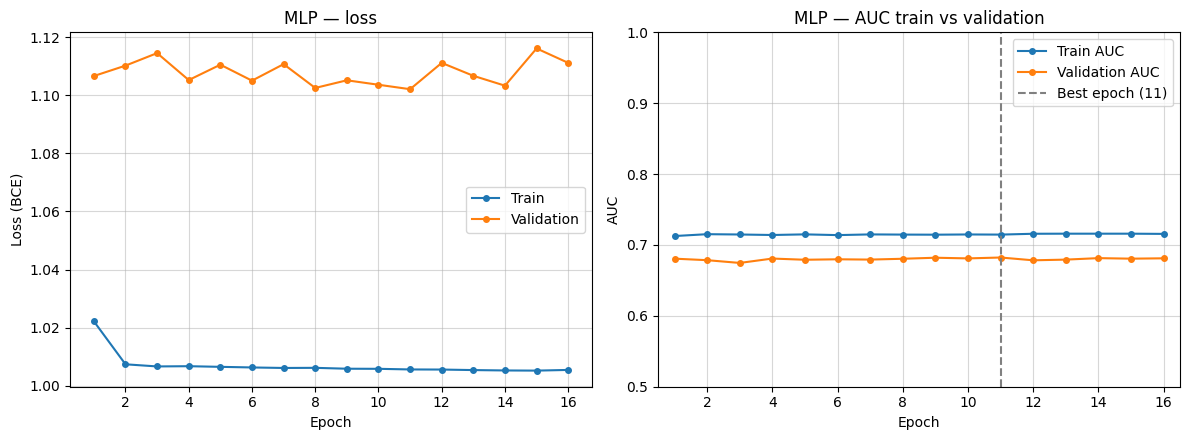

In [ ]:
## Learning curve — MLP multi-task (loss e AUC for both targets)

epochs_range = list(range(1, len(train_auc_arr_history) + 1))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(epochs_range, train_loss_arr_history, marker="o", markersize=4, label="Train")
axes[0,0].plot(epochs_range, val_loss_arr_history, marker="o", markersize=4, label="Validation")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss (BCE)")
axes[0,0].set_title("ARR_DELAY — loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.5)

axes[0,1].plot(epochs_range, train_auc_arr_history, marker="o", markersize=4, label="Train")
axes[0,1].plot(epochs_range, val_auc_arr_history, marker="o", markersize=4, label="Validation")
best_epoch_arr = epochs_range[val_auc_arr_history.index(max(val_auc_arr_history))]
axes[0,1].axvline(best_epoch_arr, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_arr})")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("AUC"); axes[0,1].set_ylim(0.5, 1)
axes[0,1].set_title("ARR_DELAY — AUC"); axes[0,1].legend(); axes[0,1].grid(alpha=0.5)

axes[1,0].plot(epochs_range, train_loss_dep_history, marker="o", markersize=4, label="Train")
axes[1,0].plot(epochs_range, val_loss_dep_history, marker="o", markersize=4, label="Validation")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss (BCE)")
axes[1,0].set_title("DEP_DELAY — loss"); axes[1,0].legend(); axes[1,0].grid(alpha=0.5)

axes[1,1].plot(epochs_range, train_auc_dep_history, marker="o", markersize=4, label="Train")
axes[1,1].plot(epochs_range, val_auc_dep_history, marker="o", markersize=4, label="Validation")
best_epoch_dep = epochs_range[val_auc_dep_history.index(max(val_auc_dep_history))]
axes[1,1].axvline(best_epoch_dep, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_dep})")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("AUC"); axes[1,1].set_ylim(0.5, 1)
axes[1,1].set_title("DEP_DELAY — AUC"); axes[1,1].legend(); axes[1,1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig(data_dir + "mlp_learning_curve_multitask.png", dpi=150)
plt.show()

## Subgroup evaluation
AUC broken down by month and by top-volume origin airport, to check for seasonal drift or geographic bias not visible in the aggregate metric.

In [ ]:
## Subgroup evaluation — MLP, for both targets

def subgroup_report_mlp(y_prob_test, target_col, group_col, threshold, top_n=None, min_support=30):
    tmp = test[[group_col, target_col]].copy()
    tmp["y_prob"] = y_prob_test
    tmp["y_pred"] = (y_prob_test > threshold).astype(int)
    rows = []
    for group_val, sub in tmp.groupby(group_col):
        if len(sub) < min_support or sub[target_col].nunique() < 2:
            continue
        rows.append({"group": group_val, "n": len(sub),
                      "auc": roc_auc_score(sub[target_col], sub["y_prob"]),
                      "f1": f1_score(sub[target_col], sub["y_pred"])})
    result = pd.DataFrame(rows).sort_values("n", ascending=False)
    return result.head(top_n).reset_index(drop=True) if top_n else result.reset_index(drop=True)


y_prob_test_arr = predict_in_batches(model_mlp, X_cat_test, X_cont_test, head="arr")
y_prob_test_dep = predict_in_batches(model_mlp, X_cat_test, X_cont_test, head="dep")
threshold_arr = find_best_threshold_mlp(model_mlp, X_cat_val, X_cont_val, y_arr_val, head="arr")
threshold_dep = find_best_threshold_mlp(model_mlp, X_cat_val, X_cont_val, y_dep_val, head="dep")

print(">>> ARR — by month")
print(subgroup_report_mlp(y_prob_test_arr, "ARR_DELAY_BIN", "FL_MONTH", threshold_arr))
print("\n>>> ARR — top 10 airports")
print(subgroup_report_mlp(y_prob_test_arr, "ARR_DELAY_BIN", "ORIGIN_INDEX", threshold_arr, top_n=10))

print("\n>>> DEP — by month")
print(subgroup_report_mlp(y_prob_test_dep, "DEP_DELAY_BIN", "FL_MONTH", threshold_dep))
print("\n>>> DEP — top 10 airports")
print(subgroup_report_mlp(y_prob_test_dep, "DEP_DELAY_BIN", "ORIGIN_INDEX", threshold_dep, top_n=10))

Best threshold (on val, max F1): 0.50
>>> MLP — by month
   group       n       auc        f1
0      1  587505  0.648756  0.315302
1      3  558183  0.638130  0.305213
2      2  554548  0.638704  0.282082
3     11  554183  0.662267  0.367043
4     10  357051  0.668723  0.383312

>>> MLP — top 10 airports
   group       n       auc        f1
0     20  130355  0.644130  0.290976
1     84  112837  0.624769  0.339763
2     83  112528  0.639877  0.364446
3    224   99190  0.578809  0.291251
4     64   76274  0.637047  0.347297
5    173   74604  0.630370  0.312175
6    171   74406  0.633739  0.375723
7    235   69576  0.632803  0.305280
8    273   64146  0.573872  0.288849
9    190   63046  0.677679  0.418514


## SHAP interpretability (model-agnostic)
A gradient-based SHAP explainer doesn't work with categorical embeddings (it tries to interpolate between category indices, which is meaningless), so a permutation-based, black-box explainer is used instead, wrapped around the model's predict function.

In [ ]:
## SHAP — MLP (model-agnostic)
def make_predict_fn(head):
    """Genera una funzione predict_fn dedicata a un singolo task (arr o dep),
    dato che SHAP si aspetta un modello con un solo output."""
    def predict_fn_mlp(X):
        X = np.asarray(X)
        n_cat = len(cat_cols)
        x_cat_np = np.round(X[:, :n_cat]).astype("int64")
        for i, col in enumerate(cat_cols):
            x_cat_np[:, i] = np.clip(x_cat_np[:, i], 0, cardinalities[col] - 1)
        x_cat = torch.tensor(x_cat_np, dtype=torch.long).to(device)
        x_cont = torch.tensor(X[:, n_cat:], dtype=torch.float32).to(device)
        with torch.no_grad():
            logit_arr, logit_dep = model_mlp(x_cat, x_cont)
            logit = logit_arr if head == "arr" else logit_dep
            prob = torch.sigmoid(logit).cpu().numpy()
        return prob
    return predict_fn_mlp


feature_cols_shap = cat_cols + continuous_cols
X_cat_clean = test[cat_cols].copy()
for col in cat_cols:
    X_cat_clean[col] = X_cat_clean[col].clip(lower=-1).replace(-1, cardinalities[col] - 1)
X_all_test = np.concatenate([X_cat_clean.values.astype("float64"), test[continuous_cols].values.astype("float64")], axis=1)

background = X_all_test[np.random.choice(len(X_all_test), 100, replace=False)]
sample = X_all_test[np.random.choice(len(X_all_test), 500, replace=False)]

shap_results = {}
for head in ["arr", "dep"]:
    explainer = shap.Explainer(make_predict_fn(head), background, algorithm="permutation")
    shap_values = explainer(sample)
    mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols_shap).sort_values(ascending=False)
    shap_results[head] = mean_abs_shap
    print(f"\n[{head}] Top 10 features by mean |SHAP|:")
    print(mean_abs_shap.head(10))

PermutationExplainer explainer: 501it [00:16, 13.28it/s]                         

Top 10 features (MLP) by mean |SHAP|:
great_circle_km         0.000503
CRS_ELAPSED_TIME        0.000397
CRS_DEP_TIME_MIN        0.000197
CRS_ARR_TIME_MIN        0.000030
D_LONGITUDE             0.000022
O_LONGITUDE             0.000021
origin_congestion_2h    0.000010
D_TEMP                  0.000005
D_LATITUDE              0.000002
OP_CARRIER              0.000002
dtype: float64


## Permutation feature importance
Measures the AUC drop from shuffling each feature independently.

In [ ]:
## Feature importance — MLP (permutation importance)

import os

RESULTS_DIR = data_dir + "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

def permutation_importance_mlp(model, X_cat, X_cont, y_true, feature_cols_cat, feature_cols_cont, head="arr", n_repeats=3, seed=42):
    rng = np.random.default_rng(seed)
    baseline_prob = predict_in_batches(model, X_cat, X_cont, head=head)
    baseline_auc = roc_auc_score(y_true.cpu().numpy(), baseline_prob)
    print(f"[{head}] Baseline AUC (no permutation): {baseline_auc:.4f}")

    importances = {}
    for i, col in enumerate(feature_cols_cat):
        drops = []
        for _ in range(n_repeats):
            X_cat_perm = X_cat.clone()
            perm_idx = torch.tensor(rng.permutation(X_cat.shape[0]))
            X_cat_perm[:, i] = X_cat[perm_idx, i]
            prob_perm = predict_in_batches(model, X_cat_perm, X_cont, head=head)
            drops.append(baseline_auc - roc_auc_score(y_true.cpu().numpy(), prob_perm))
        importances[col] = np.mean(drops)

    for i, col in enumerate(feature_cols_cont):
        drops = []
        for _ in range(n_repeats):
            X_cont_perm = X_cont.clone()
            perm_idx = torch.tensor(rng.permutation(X_cont.shape[0]))
            X_cont_perm[:, i] = X_cont[perm_idx, i]
            prob_perm = predict_in_batches(model, X_cat, X_cont_perm, head=head)
            drops.append(baseline_auc - roc_auc_score(y_true.cpu().numpy(), prob_perm))
        importances[col] = np.mean(drops)

    return pd.Series(importances).sort_values(ascending=False)


importance_mlp_arr = permutation_importance_mlp(model_mlp, X_cat_test, X_cont_test, y_arr_test, cat_cols, continuous_cols, head="arr")
print("\nTop 15 features (ARR, permutation importance — AUC drop):")
print(importance_mlp_arr.head(15))
importance_mlp_arr.to_csv(RESULTS_DIR + "mlp_feature_importance_arr.csv")

importance_mlp_dep = permutation_importance_mlp(model_mlp, X_cat_test, X_cont_test, y_dep_test, cat_cols, continuous_cols, head="dep")
print("\nTop 15 features (DEP, permutation importance — AUC drop):")
print(importance_mlp_dep.head(15))
importance_mlp_dep.to_csv(RESULTS_DIR + "mlp_feature_importance_dep.csv")

Baseline AUC (no permutation): 0.6449

Top 15 features (MLP, permutation importance — AUC drop):
great_circle_km     0.064071
CRS_ELAPSED_TIME    0.049948
OP_CARRIER          0.027520
dep_hour_sin        0.024216
CRS_DEP_TIME_MIN    0.019260
arr_hour_cos        0.011150
O_PRCP              0.007119
D_PRCP              0.006466
month_cos           0.006238
ORIGIN_INDEX        0.005795
DEST_INDEX          0.004832
O_LONGITUDE         0.003577
dep_hour_cos        0.003329
FL_WEEK             0.002720
D_LONGITUDE         0.002594
dtype: float64


In [ ]:
## Saving MLP weights for fusion with LSTM

model_mlp.eval()   # disable Dropout: crucial before saving, otherwise
                    # anyone reloading the model risks non-deterministic predictions
                    # if they forget to call eval() after loading

model_weights_path = data_dir + "mlp_weights.pt"
torch.save(model_mlp.state_dict(), model_weights_path)
print(f"Weights saved successfully in: {model_weights_path}")

Weights saved successfully in: /content/drive/MyDrive/aeolus_22_23/mlp_weights.pt
